# Atividade 2 - Econometria

---

## Questão 1: Importação da Base de Dados

### Importação dos dados

Os dados foram obtidos do Sistema Gerenciador de Séries Temporais (SGS) do Banco Central do Brasil. As séries utilizadas são:

| Variável | Código SGS | Descrição |
|----------|------------|-----------|
| `ibc` | 24363 | Índice de Atividade Econômica do Banco Central (IBC-Br) |
| `selic` | 4390 | Taxa Selic |
| `ipca` | 433 | Índice Nacional de Preços ao Consumidor Amplo |
| `cambio_livre` | 3698 | Taxa de câmbio livre (R$/US$) |
| `saldo_carteira` | 20539 | Saldo da carteira de crédito |

In [28]:
import pandas as pd

def carregar(codigo, nome):
    caminho = rf"C:\Users\pedro\OneDrive\Documentos\econometria\data\bcdata.sgs.{codigo}.csv"
    # Lê, faz o parse da data, define como índice e renomeia a coluna 'valor'
    df = pd.read_csv(caminho, sep=';', decimal=',', parse_dates=['data'], dayfirst=True, index_col='data')
    return df.rename(columns={'valor': nome})

series = {
    "ibc": 24363,
    "selic": 4390,
    "ipca": 433,
    "cambio_livre": 3698,
    "saldo_carteira": 20539
}

# Comprehension chamando a função com código e nome
dfs = {nome: carregar(cod, nome) for nome, cod in series.items()}


In [29]:
# Unindo todas as séries em um único DataFrame
df_macro = pd.concat(dfs.values(), axis=1, join='inner')
df_macro.head()

,ibc,selic,ipca,cambio_livre,saldo_carteira
data,,,,,
2010-01-01,87.95497,0.66,0.75,1.7798,1430550
2010-02-01,89.21251,0.59,0.78,1.8416,1441519
2010-03-01,100.28025,0.76,0.52,1.7858,1458091
2010-04-01,95.68569,0.67,0.57,1.7566,1474310
2010-05-01,95.44154,0.75,0.43,1.8132,1505517


### a) Número de observações

In [30]:
print(f"Número de observações: {len(df_macro)}")
print(f"Período: {df_macro.index.min().date()} a {df_macro.index.max().date()}")

Número de observações: 180
Período: 2010-01-01 a 2024-12-01


### b) Descrição das variáveis

In [31]:
df_macro.describe()

,ibc,selic,ipca,cambio_livre,saldo_carteira
count,180.000000,180.000000,180.000000,180.000000,1.800000e+02
mean,98.531165,0.753833,0.477167,3.574281,3.425290e+06
std,4.860712,0.272819,0.359810,1.367291,1.269797e+06
min,83.958150,0.130000,-0.680000,1.563900,1.430550e+06
25%,95.412688,0.540000,0.247500,2.230750,2.606028e+06
50%,98.014010,0.810000,0.450000,3.469400,3.127621e+06
75%,101.775780,0.952500,0.710000,4.980775,4.112071e+06
max,111.550020,1.220000,1.620000,6.097000,6.464602e+06


### c) Identificação da variável dependente e explicativas

- **Variável dependente (Y):** `ibc` - Índice de Atividade Econômica do Banco Central (proxy do PIB mensal)

- **Variáveis explicativas (X):**
  - `selic` - Taxa básica de juros
  - `ipca` - Inflação
  - `cambio_livre` - Taxa de câmbio
  - `saldo_carteira` - Crédito na economia

## Questão 2
Estime um modelo de regress˜ao m´ultipla por MQO.

a) equação estimada


In [32]:
import statsmodels.api as sm

# separando a variável dependente (y) e as independentes (X)
Y = df_macro['ibc']
X = df_macro[['selic', 'ipca', 'cambio_livre', 'saldo_carteira']]

# adicionando uma constante para o modelo
X = sm.add_constant(X)

# estimar o modelo de regressão linear
model = sm.OLS(Y, X).fit()

# exibir o resumo do modelo
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    ibc   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     40.24
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           7.07e-24
Time:                        15:22:46   Log-Likelihood:                -480.82
No. Observations:                 180   AIC:                             971.6
Df Residuals:                     175   BIC:                             987.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             97.2766      1.274     76.

#### b) Interpretação economica

1. Selic negativa - faz sentido, juros altos encarecem crédito, desestimulam investimento e consumo -> economia desacelera
2. IPCA não foi estatisticamente significativo neste modelo (p = 0.78 > 0.05), o que pode estar relacionado à multicolinearidade ou ao fato de a inflação mensal não capturar bem os efeitos de curto prazo sobre a atividade
3. Câmbio negativo - dólar alto encarece importações, insumos, gera incerteza → reduz atividade
4. Crédito positivo - mais crédito na economia → mais consumo e investimento → economia aquece

#### c) R2
O r2 deu 0.479, ou seja, mais ou menos 48% da variação do IBC. Os outros 52% são explicados por fatores não incluídos no modelo.
O aviso de multicolinearidade sugere que algumas variáveis explicativas estão correlacionadas entre si (ex: selic e ipca costumam andar juntos). Isso pode inflar os erros-padrão.

---

## Questão 3: Heterocedasticidade (Teoria)

### a) O que é heterocedasticidade?
A heterocedasticidade é um erro que pode acontecer em modelos de regressão quando a variância do erro não permanece constante ao longo das observações, o que significa que independente do valor de X, a variância deve permanecer a mesma segundo os pressupostos do modelo clássico. Quando esse conceito é violado, a variância do erro começam a depender de X, ou seja, a dispersão dos resíduos aumenta ou diminui conforme muda a variável explicativa


### b) Por que ela viola uma hipótese do Modelo Clássico?
Como falei antes, ela viola uma hipótese do modelo clássico porque esse modelo pressupõe que a variância do termo de erro seja constante para todas as observações, independentemente do valor das variáveis explicativas.



### c) Quais são suas consequências para os estimadores de MQO?
Apesar da heterocedasticidade não alterar os valores esperados dos estimadores, eles deixam de ser eficientes, pelo Teorema de Gauss-Markov, sob homocedasticidade, o MQO é o estimador linear não viesado de menor variância. Além disso, os erros-padrão estimados pela fórmula tradicional tornam-se incorretos, comprometendo a validade dos testes de hipótese, dos intervalos de confiança e das estatísticas t e F.



---

## Questão 4: Teste de Heterocedasticidade

### a) Teste de Breusch-Pagan

In [33]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']

print("Teste de Breusch-Pagan:")
for label, value in zip(labels, bp_test):
    print(f"  {label}: {value:.4f}")

# Lm Statistic: estatistica do teste de Breusch-Pagan, que segue uma distribuição qui-quadrado sob a hipótese nula de homocedasticidade.
# LM p-value: valor-p associado à estatística do teste, que indica a probabilidade de observar uma estatística tão extrema quanto a calculada, assumindo que a hipótese nula seja verdadeira.
# F-Statistic: estatística F do teste de Breusch-Pagan, que também segue uma distribuição F sob a hipótese nula de homocedasticidade.
# F p-value: valor-p associado à estatística F, que indica a probabilidade de observar uma estatística F tão extrema quanto a calculada, assumindo que a hipótese nula seja verdadeira.

Teste de Breusch-Pagan:
  LM Statistic: 1.6750
  LM p-value: 0.7953
  F-Statistic: 0.4109
  F p-value: 0.8006


### b) Hipóteses do teste

- **H₀:** Homocedasticidade (variância dos erros é constante)
- **H₁:** Heterocedasticidade (variância dos erros não é constante)

### c) Interpretação dos resultados
Levando em conta o nível de significância 0.05, o resultado de LM p-value: 0.7953 nos leva a não rejeitar H0, não há evidência estatística de heterocedasticidade nos resíduos. A variência dos erros pode ser considerada constante. O que é uma boa notícia para o modelo, significa que os erros-padrão do MQO estão corretos e os testes t são confiáveis.



---

## Questão 5: Erros-Padrão Robustos

### a) Estimação com erros-padrão robustos

In [ ]:
# Modelo com erros-padrão robustos (HC1 - correção de White para heterocedasticidade)
modelo_robusto = model.get_robustcov_results(cov_type='HC1')
print(modelo_robusto.summary())

# Nota: HC1 corrige para heterocedasticidade. Como nosso diagnóstico apontou 
# autocorrelação (e não heterocedasticidade), uma alternativa seria usar HAC 
# (Newey-West), que corrige para ambos os problemas simultaneamente.

### b) Comparação com a regressão original

In [35]:
# Comparação dos erros-padrão
comparacao = pd.DataFrame({
    'Coef': model.params,
    'SE (MQO)': model.bse,
    'SE (Robusto)': modelo_robusto.bse,
    'p-valor (MQO)': model.pvalues,
    'p-valor (Robusto)': modelo_robusto.pvalues
})
comparacao

,Coef,SE (MQO),SE (Robusto),p-valor (MQO),p-valor (Robusto)
const,97.276583,1.273557e+00,1.341961e+00,2.544753e-136,1.822732e-132
selic,-2.841397,1.241770e+00,1.229552e+00,2.332277e-02,2.200337e-02
ipca,0.201868,7.384651e-01,8.215620e-01,7.848979e-01,8.061930e-01
cambio_livre,-5.338417,5.447705e-01,5.853162e-01,2.386916e-18,1.748328e-16
saldo_carteira,0.000007,5.779398e-07,6.114998e-07,1.335615e-22,7.796247e-21


### c) Houve alteração nas conclusões dos testes t?

Não houve alteração significativa. As variáveis que eram significativas (selic, cambio_livre, saldo_carteira) continuaram significativas, e o IPCA continuou não significativo.

**Por que os erros robustos produzem resultados semelhantes?**

Como o teste de Breusch-Pagan não rejeitou a hipótese de homocedasticidade (p = 0.80), não há evidência de heterocedasticidade nos dados. Os erros-padrão robustos (HC1) são uma correção para quando a variância dos erros não é constante. Quando a variância já é constante (como no nosso caso), a correção não tem muito o que corrigir — os erros-padrão robustos convergem para os erros-padrão convencionais. Por isso os valores ficaram tão parecidos: estamos aplicando uma correção para um problema que não existe.

Isso confirma o diagnóstico do Breusch-Pagan: se houvesse heterocedasticidade, os erros robustos seriam diferentes dos convencionais.


---

## Questão 6: Autocorrelação (Teoria)

### a) Quando esse problema costuma ocorrer?

A autocorrelação costuma ocorrer principalmente em séries temporais, quando os dados têm uma ordem cronológica. Por exemplo, o PIB de janeiro tende a influenciar o PIB de fevereiro, a inflação de um mês afeta a do mês seguinte, etc. Também pode surgir quando o modelo omite variáveis importantes que têm comportamento temporal, ou quando a forma funcional do modelo está mal especificada.

### b) Quais hipóteses do MCRL são violadas?

A autocorrelação viola a hipótese de que os erros são não correlacionados entre si, ou seja, Cov(εᵢ, εⱼ) = 0 para i ≠ j. No modelo clássico, assume-se que o erro de uma observação não tem relação com o erro de outra observação. Quando existe autocorrelação, os erros passam a ser correlacionados ao longo do tempo.

### c) Quais consequências surgem para a inferência estatística?

Assim como na heterocedasticidade, os estimadores de MQO continuam não viesados, mas deixam de ser eficientes (não são mais os de menor variância). O problema principal é que os erros-padrão calculados pela fórmula convencional ficam incorretos, geralmente subestimados. Isso faz com que os testes t e F fiquem inflados, levando a rejeitar H₀ com mais frequência do que deveríamos, ou seja, encontramos significância estatística onde talvez não exista.


---

## Questão 7: Teste de Autocorrelação

### a) Hipóteses do teste

- **H₀:** Não há autocorrelação nos resíduos
- **H₁:** Há autocorrelação nos resíduos

### b) Estatística obtida

In [36]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# Teste Durbin-Watson
dw = durbin_watson(model.resid)
print(f"Durbin-Watson: {dw:.4f}")
print("  (DW ≈ 2: sem autocorrelação | DW < 2: autocorrelação positiva | DW > 2: autocorrelação negativa)")

# Teste Breusch-Godfrey
bg_test = acorr_breusch_godfrey(model, nlags=1)
print(f"\nBreusch-Godfrey (lag=1):")
print(f"  LM Statistic: {bg_test[0]:.4f}")
print(f"  p-value: {bg_test[1]:.4f}")

Durbin-Watson: 1.1612
  (DW ≈ 2: sem autocorrelação | DW < 2: autocorrelação positiva | DW > 2: autocorrelação negativa)

Breusch-Godfrey (lag=1):
  LM Statistic: 29.9459
  p-value: 0.0000


### c) Conclusão

O Durbin-Watson deu 1.1612, que está bem abaixo de 2, indicando autocorrelação positiva. O teste de Breusch-Godfrey confirmou isso com um p-valor praticamente zero (0.0000), rejeitando fortemente a hipótese nula de ausência de autocorrelação. Portanto, existe autocorrelação positiva nos resíduos do modelo, o que significa que erros positivos tendem a ser seguidos por erros positivos, e erros negativos por erros negativos. Isso é comum em dados macroeconômicos mensais como os que estamos usando.


---

## Questão 8: Gráfico dos Resíduos

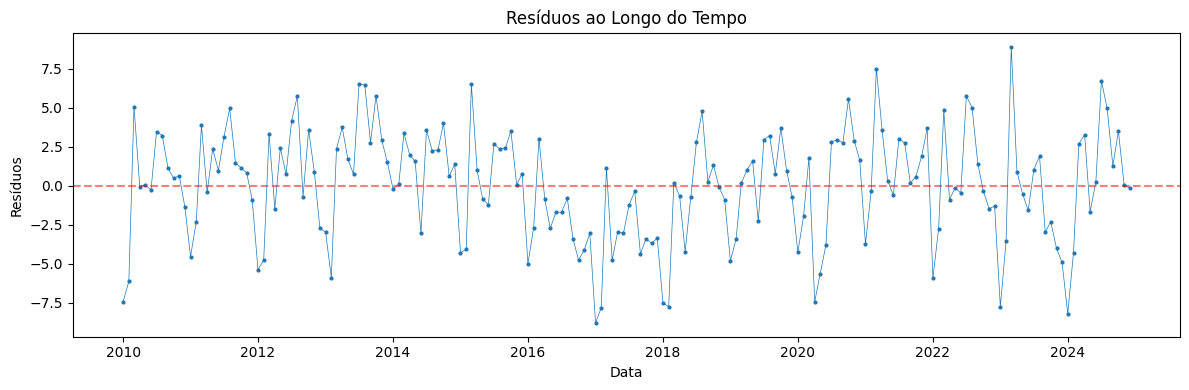

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(model.resid.index, model.resid, marker='o', markersize=2, linewidth=0.5)
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Data')
ax.set_ylabel('Resíduos')
ax.set_title('Resíduos ao Longo do Tempo')
plt.tight_layout()
plt.show()

**Discussão:** 

O gráfico mostra os resíduos oscilando em torno de zero ao longo do tempo. O padrão mais evidente é a queda brusca em 2020, que corresponde ao início da pandemia de COVID-19 — um choque que derrubou a atividade econômica de forma abrupta e que o modelo não consegue capturar apenas com as variáveis incluídas.

Observam-se também alguns agrupamentos de resíduos com o mesmo sinal em determinados períodos, o que sugere autocorrelação positiva. Isso é confirmado pelos testes estatísticos: o Durbin-Watson de 1.16 (distante de 2) e o p-valor do Breusch-Godfrey próximo de zero indicam que erros de um período tendem a ser seguidos por erros de mesmo sinal no período seguinte. Esse comportamento é típico em séries temporais macroeconômicas, onde a economia de um mês influencia a do mês seguinte.


---

## Questão 9: Multicolinearidade (Teoria)

### a) Diferença entre multicolinearidade perfeita e imperfeita

Na multicolinearidade perfeita, uma variável explicativa é uma combinação linear exata de outras. Por exemplo, se X₃ = 2X₁ + 3X₂. Nesse caso, o MQO simplesmente não funciona, o sistema não tem solução única. Na multicolinearidade imperfeita, existe uma correlação alta entre as variáveis, mas não é exata. O MQO funciona, mas os resultados ficam instáveis. Na prática, o que encontramos é quase sempre a imperfeita.

### b) Efeitos sobre os estimadores

Diferente da heterocedasticidade e autocorrelação, a multicolinearidade não viola nenhuma hipótese do MCRL, então os estimadores continuam sendo BLUE (não viesados e de menor variância dentro da classe linear). O problema é que as variâncias dos estimadores ficam muito grandes, resultando em erros-padrão inflados. Isso faz com que os intervalos de confiança fiquem largos e os testes t percam poder, dificultando encontrar significância estatística mesmo quando a variável tem efeito real.

### c) Por que esse problema dificulta a interpretação econômica?

Quando duas variáveis são muito correlacionadas, fica difícil separar o efeito individual de cada uma. Por exemplo, no nosso modelo, câmbio e saldo_carteira têm correlação de 0.89. Se ambos sobem juntos ao longo do tempo, como saber quanto do efeito no IBC vem do câmbio e quanto vem do crédito? Os coeficientes ficam instáveis e podem até trocar de sinal dependendo de pequenas mudanças nos dados. Isso torna a interpretação econômica pouco confiável.


---

## Questão 10: Investigação de Multicolinearidade

### a) Matriz de correlação

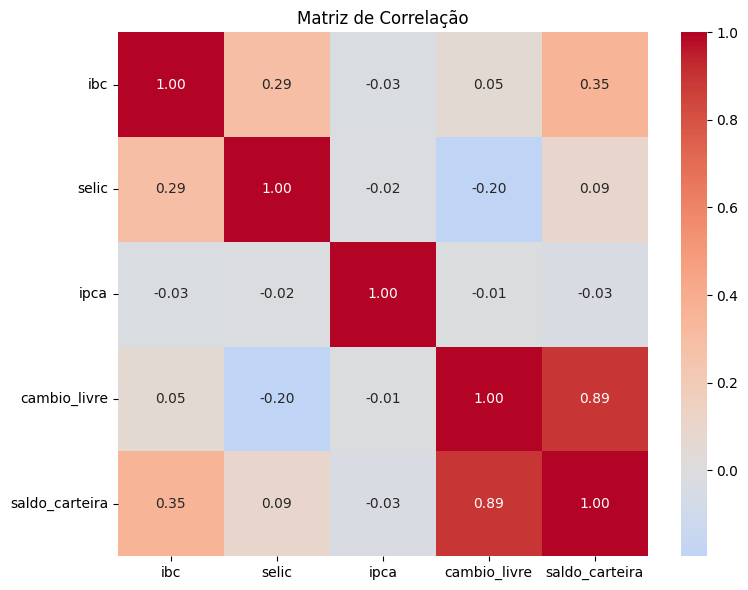

In [38]:
import seaborn as sns

# Matriz de correlação
corr_matrix = df_macro.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

### b) Fator de Inflação da Variância (VIF)

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcular VIF para cada variável
X_vif = df_macro[['selic', 'ipca', 'cambio_livre', 'saldo_carteira']]
vif_data = pd.DataFrame()
vif_data['Variável'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)
print("\n(VIF > 10: multicolinearidade severa | VIF > 5: multicolinearidade moderada)")

         Variável        VIF
0           selic   6.412372
1            ipca   2.561413
2    cambio_livre  45.219449
3  saldo_carteira  58.078958

(VIF > 10: multicolinearidade severa | VIF > 5: multicolinearidade moderada)


### c) Interpretação dos resultados

A matriz de correlação mostra que cambio_livre e saldo_carteira têm correlação de 0.89, que é muito alta. Isso explica por que os VIFs dessas variáveis são tão elevados (45.22 e 58.08, respectivamente). A selic tem VIF de 6.41, que indica multicolinearidade moderada. Já o IPCA tem VIF de 2.56, que está dentro do aceitável.

O problema é que tanto o câmbio quanto o crédito seguiram tendências de crescimento ao longo de 2010-2024: o dólar saiu de ~R$1.80 para ~R$5-6, e o saldo de crédito também cresceu continuamente. Essa tendência temporal comum gera uma correlação espúria entre as duas variáveis, dificultando a separação dos seus efeitos individuais sobre o IBC.


---

## Questão 11: Estratégia para Reduzir Multicolinearidade

**Estratégia proposta:**

Uma opção seria trabalhar com as variáveis em primeira diferença (variação mensal) ao invés de usar os níveis. Por exemplo, usar Δcambio (variação do câmbio) e Δsaldo_carteira (variação do crédito). Isso remove a tendência temporal que está causando a correlação espúria entre as variáveis. Outra alternativa seria remover uma das variáveis problemáticas do modelo, mantendo apenas câmbio ou apenas crédito.

**Vantagens:**

Usar diferenças elimina a tendência comum e reduz drasticamente a correlação entre as variáveis. Os VIFs cairiam para níveis aceitáveis e os coeficientes ficariam mais estáveis e interpretáveis. Além disso, em séries temporais, trabalhar com variações costuma fazer mais sentido economicamente (o que importa é a mudança, não o nível).

**Desvantagens:**

Ao diferenciar, perdemos informação sobre a relação de longo prazo entre as variáveis. Também perdemos uma observação no início da série. Se optarmos por remover uma variável, perdemos poder explicativo e podemos introduzir viés de variável omitida caso a variável removida seja relevante.


---

## Questão 12: Verdadeiro ou Falso

### a) A heterocedasticidade torna os estimadores de MQO viesados.
 FALSO. A heterocedasticidade não causa viés nos estimadores. Eles continuam não viesados, mas deixam de ser eficientes (não são mais os de menor variância). O problema principal é que os erros-padrão ficam incorretos, comprometendo os testes de hipótese.

### b) A autocorrelação afeta a eficiência dos estimadores.
 VERDADEIRO. Assim como a heterocedasticidade, a autocorrelação faz com que os estimadores de MQO deixem de ser os mais eficientes. Eles perdem a propriedade de menor variância, e os erros-padrão calculados pela fórmula convencional ficam incorretos.

### c) A multicolinearidade aumenta os erros-padrão dos coeficientes.
 VERDADEIRO. Quanto maior a correlação entre as variáveis explicativas, maiores ficam as variâncias dos estimadores e, consequentemente, maiores os erros-padrão. Isso dificulta encontrar significância estatística e torna os coeficientes instáveis.

### d) Um elevado R² garante ausência de problemas econométricos.
FALSO. O R² mede apenas o ajuste do modelo aos dados, não garante nada sobre as hipóteses do MCRL. É perfeitamente possível ter um R² alto e ainda assim ter heterocedasticidade, autocorrelação ou multicolinearidade. No nosso modelo, por exemplo, temos R² = 0.48, mas detectamos autocorrelação e multicolinearidade severa.


---

## Questão 13: Heterocedasticidade e Autocorrelação Simultâneas

### a) Quais procedimentos podem ser utilizados para corrigir esses problemas?

Existem algumas opções: usar erros-padrão robustos HAC (Newey-West), que corrigem simultaneamente para heterocedasticidade e autocorrelação; estimar por Mínimos Quadrados Generalizados (GLS/FGLS), que leva em conta a estrutura de correlação dos erros; ou usar modelos específicos para séries temporais como ARIMA ou incluir defasagens da variável dependente como regressor.

### b) Em quais situações o uso de erros-padrão robustos é suficiente?

Os erros robustos são suficientes quando o objetivo principal é fazer inferência (testes de hipótese e intervalos de confiança) e não necessariamente obter os estimadores mais eficientes. Se a amostra é grande o suficiente e o interesse é apenas corrigir os erros-padrão para fazer testes válidos, os erros HAC funcionam bem. É uma solução prática que não exige especificar a estrutura exata da autocorrelação.

### c) Quando seria recomendável utilizar MQG (GLS ou FGLS)?

O MQG é recomendável quando queremos estimadores mais eficientes, não apenas erros-padrão corretos. Se conhecemos ou conseguimos estimar bem a estrutura de correlação dos erros (por exemplo, um processo AR(1)), o GLS/FGLS vai produzir estimadores com menor variância que o MQO. Também é mais indicado quando a amostra é pequena, pois os erros robustos dependem de propriedades assintóticas.


---

## Questão 14: Relacione os Testes de Diagnóstico

- Durbin-Watson → (II) Autocorrelação
- VIF → (III) Multicolinearidade
- White → (I) Heterocedasticidade
- Breusch-Godfrey → (II) Autocorrelação
- Breusch-Pagan → (I) Heterocedasticidade

- Durbin-Watson: Detecta autocorrelação de primeira ordem nos resíduos. Valores próximos de 2 indicam ausência de autocorrelação, abaixo de 2 indica autocorrelação positiva e acima de 2 indica autocorrelação negativa.

- VIF: Mede o quanto a variância de um coeficiente é inflada devido à correlação com outras variáveis explicativas. VIF > 10 indica multicolinearidade severa, VIF > 5 indica multicolinearidade moderada.

- White: Testa heterocedasticidade de forma geral, sem assumir uma forma específica. Verifica se a variância dos erros depende das variáveis explicativas ou de seus produtos cruzados.

- Breusch-Godfrey: Testa autocorrelação nos resíduos, permitindo testar ordens mais altas (não só lag 1). É mais geral que o Durbin-Watson e funciona mesmo com variáveis dependentes defasadas.

- Breusch-Pagan: Testa heterocedasticidade verificando se a variância dos erros está relacionada com as variáveis explicativas. A hipótese nula é homocedasticidade.


---

## Questão 15: Parecer Técnico

### Qualidade do ajuste do modelo

O modelo apresenta R² = 0.479, indicando que as quatro variáveis explicativas (selic, ipca, cambio_livre e saldo_carteira) explicam aproximadamente 48% da variação do IBC-Br. É um ajuste razoável para dados macroeconômicos, mas significa que mais da metade da variação permanece não explicada por fatores não incluídos no modelo.

### Existência de heterocedasticidade

O teste de Breusch-Pagan apresentou p-valor de 0.7953, bem acima do nível de significância de 5%. Portanto, não rejeitamos a hipótese nula de homocedasticidade. Não há evidência de heterocedasticidade nos resíduos, o que é uma boa notícia para a validade dos erros-padrão convencionais.

### Existência de autocorrelação

O teste de Durbin-Watson resultou em 1.1612, distante do valor ideal de 2, indicando autocorrelação positiva. O teste de Breusch-Godfrey confirmou com p-valor praticamente zero. Existe autocorrelação significativa nos resíduos, o que é esperado em séries temporais macroeconômicas mensais onde os valores de um período influenciam os do período seguinte.

### Existência de multicolinearidade

A análise de VIF revelou multicolinearidade severa entre cambio_livre (VIF = 45.22) e saldo_carteira (VIF = 58.08). A matriz de correlação mostra correlação de 0.89 entre essas variáveis. Isso ocorre porque ambas seguiram tendências de crescimento ao longo do período analisado, gerando correlação espúria.

### Consequências para a inferência econométrica

A autocorrelação faz com que os erros-padrão convencionais sejam incorretos, comprometendo a validade dos testes t e intervalos de confiança. A multicolinearidade infla os erros-padrão das variáveis afetadas, tornando difícil identificar o efeito individual de cada uma sobre o IBC. Os coeficientes de câmbio e crédito devem ser interpretados com cautela.

### Possíveis medidas corretivas

Para a autocorrelação: usar erros-padrão HAC (Newey-West) ou estimar por GLS/FGLS. Para a multicolinearidade: trabalhar com as variáveis em primeira diferença para remover a tendência temporal, ou remover uma das variáveis problemáticas do modelo. Outra opção seria incluir uma variável de tendência temporal para capturar o efeito comum.

### Conclusão final sobre a confiabilidade do modelo

O modelo estimado por MQO apresenta problemas que comprometem parcialmente sua confiabilidade. Embora não haja heterocedasticidade, a presença de autocorrelação e multicolinearidade severa exige cautela na interpretação dos resultados. Os coeficientes são não viesados, mas os erros-padrão estão incorretos devido à autocorrelação, e a multicolinearidade dificulta separar os efeitos de câmbio e crédito. Para uso em análise econômica, recomenda-se aplicar as correções sugeridas antes de tirar conclusões definitivas sobre as relações entre as variáveis.
